In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available else "cpu")


In [3]:
imsize = 256

image_transform = transforms.Compose([
    transforms.Resize((imsize, imsize)),
    transforms.ToTensor()
])

def image_loader(image_name: str):
    image = Image.open(image_name)
    image = image_transform(image).unsqueeze(0)
    return image.to(device, torch.float)

In [67]:
content_image = image_loader("image\content_img.jpg")
style_image = image_loader("image\style_img2.jpg")

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Admin\AppData\Local\Temp\ipykernel_170152\1476394932.py:1: SyntaxWarning: invalid escape sequence '\c'
  content_image = image_loader("image\content_img.jpg")
C:\Users\Admin\AppData\Local\Temp\ipykernel_170152\1476394932.py:2: SyntaxWarning: invalid escape sequence '\s'
  style_image = image_loader("image\style_img2.jpg")


In [68]:
vgg19 = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

print(vgg19)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [69]:
content_layers = ['conv_4']
style_layers = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def normalization(image):
    # .view the mean and std to make them [C x 1 x 1] so that they can
    # directly work with image Tensor of shape [B x C x H x W].
    # B is batch size. C is number of channels. H is height and W is width.
    normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
    normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)      
    mean = normalization_mean.view(-1, 1, 1)
    std = normalization_std.view(-1, 1, 1)
    return (image - mean) / std

def get_features(model, image):
    layers = {
        '0': 'conv_1',
        '5': 'conv_2',
        '10': 'conv_3',
        '19': 'conv_4',
        '28': 'conv_5'
    }
    features = {}
    x = image
    x = normalization(x) #Normalize image before feed to model
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features


In [70]:
def get_dual_style(style_features1, style_features2, style_layers):
    final_style_features = {}
    for layer in style_layers:
        sf1 = style_features1[layer]
        sf2 = style_features2[layer]
        #################### YOUR CODE HERE ###################
        channel_end_index = int(sf1.size(1) / 4)
        sf1 = sf1[:, :channel_end_index, :, :]

        sf2 = sf2[:, channel_end_index:, :, :]

        final_style_features[layer] = torch.cat((sf1, sf2), dim=1)
        ######################################################
    return final_style_features

In [71]:
def rot_style_features(style_features, style_layers):
    final_rot_style_features = {}
    for layer in style_layers:
        sf = style_features[layer].clone()
        # 2. Rotate 90 degrees.  torch.rot90 rotates *counter-clockwise*,
        #    and the dimensions are (batch, channel, height, width), so we rotate
        #    dimensions 2 and 3.  k=1 means rotate 90 degrees once.
        rot90 = torch.rot90(sf, k=1, dims=(2, 3))

        # 3. Rotate another 90 degrees (total 180).  We rotate rot90, NOT sf.
        rot180 = torch.rot90(rot90, k=1, dims=(2, 3))

        # 4. Differential evolution combination.
        final_rot = sf + (rot90 - rot180)
        final_rot_style_features[layer] = final_rot
    return final_rot_style_features

In [72]:
ContentLoss = nn.MSELoss()
StyleLoss = nn.MSELoss()

def gram_matrix(input):
    a, b, c, d = input.size()
    features = input.view(a * b, c * d)
    G = torch.mm(features, features.t())
    return G.div(a * b * c * d)


# --- Style transfer function ---
def style_tranfer_(model, optimizer, target_img,
                    content_features, style_features,
                    style_layers, content_weight, style_weight):

    optimizer.zero_grad()
    with torch.no_grad():
        target_img.clamp_(0, 1)
    target_features = get_features(model, target_img)
    content_loss = ContentLoss(content_features["conv_4"], target_features["conv_4"])


    style_loss = 0
    for layer in style_layers:
        target_gram = gram_matrix(target_features[layer])
        style_gram = gram_matrix(style_features[layer])
        style_loss += StyleLoss(style_gram, target_gram)

    total_loss = content_loss*content_weight + style_loss*style_weight
    total_loss.backward(retain_graph=True)
    optimizer.step()
    return total_loss, content_loss, style_loss

In [76]:
# --- Calculate Features (Outside the Loop) ---
content_features = get_features(vgg19, content_image)
style_features = get_features(vgg19, style_image)
final_style_features = get_dual_style(content_features, style_features, style_layers)


# --- Initialize Target Images and Optimizers ---
target_img = content_image.clone().requires_grad_(True).to(device)
optimizer = optim.Adam([target_img], lr=0.02)



# --- Training Loop ---
STEPS = 500
content_weight = 1
style_weight = 1e5
for step in range(STEPS):
    total_loss, content_loss, style_loss = style_tranfer_(
        vgg19, optimizer,
        target_img, content_features,
        style_features, style_layers,
        content_weight, style_weight)

    if step % 100 == 99:
        print(f"Epoch [{step+1}/{STEPS}] Total loss1: {total_loss.item():.6f} - \
            Content loss: {content_loss.item():.6f} - Style loss: {style_loss.item():.6f}")


    with torch.no_grad():
        target_img.clamp_(0, 1)

Epoch [100/500] Total loss1: 11.734474 -             Content loss: 6.648232 - Style loss: 0.000051
Epoch [200/500] Total loss1: 11.418949 -             Content loss: 6.587753 - Style loss: 0.000048
Epoch [300/500] Total loss1: 11.262667 -             Content loss: 6.443004 - Style loss: 0.000048
Epoch [400/500] Total loss1: 11.342643 -             Content loss: 6.525511 - Style loss: 0.000048
Epoch [500/500] Total loss1: 11.189940 -             Content loss: 6.518115 - Style loss: 0.000047


In [78]:
# --- Convert images to PIL images to display---
unloader = transforms.ToPILImage()
image = target_img.cpu().clone()
image = image.squeeze(0)
image = unloader(image)

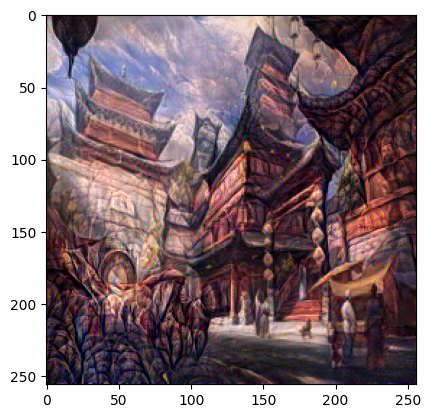

In [82]:
# --- Display the images ---
import matplotlib.pyplot as plt
plt.imshow(image)

In [73]:
# --- Calculate Features (Outside the Loop) ---
content_features = get_features(vgg19, content_image)
style_features1 = get_features(vgg19, style_image)
final_rot_style_features = rot_style_features(style_features1, style_layers)


# --- Initialize Target Images and Optimizers ---
target_img1 = content_image.clone().requires_grad_(True).to(device)
optimizer1 = optim.Adam([target_img1], lr=0.02)
target_img2 = content_image.clone().requires_grad_(True).to(device)
optimizer2 = optim.Adam([target_img2], lr=0.02)


# --- Training Loop ---
STEPS = 500
content_weight = 1
style_weight = 1e5
for step in range(STEPS):
    total_loss1, content_loss1, style_loss1 = style_tranfer_(
        vgg19, optimizer1,
        target_img1, content_features,
        style_features1, style_layers,
        content_weight, style_weight)

    total_loss2, content_loss2, style_loss2 = style_tranfer_(
        vgg19, optimizer2,
        target_img2, content_features,
        final_rot_style_features,  # Using the ROTATED features here
        style_layers, content_weight,
        style_weight)

    if step % 100 == 99:
        print(f"Epoch [{step+1}/{STEPS}] Total loss1: {total_loss1.item():.6f} - \
            Content loss1: {content_loss1.item():.6f} - Style loss1: {style_loss1.item():.6f}")
        print(f"Epoch [{step+1}/{STEPS}] Total loss2: {total_loss2.item():.6f} - \
            Content loss2: {content_loss2.item():.6f} - Style loss2: {style_loss2.item():.6f}")

    with torch.no_grad():
        target_img1.clamp_(0, 1)
        target_img2.clamp_(0, 1)  # Clamp target_img2 too


Epoch [100/500] Total loss1: 11.707350 -             Content loss1: 6.748343 - Style loss1: 0.000050
Epoch [100/500] Total loss2: 56.538162 -             Content loss2: 16.152454 - Style loss2: 0.000404
Epoch [200/500] Total loss1: 11.369797 -             Content loss1: 6.504294 - Style loss1: 0.000049
Epoch [200/500] Total loss2: 54.889362 -             Content loss2: 16.007153 - Style loss2: 0.000389
Epoch [300/500] Total loss1: 11.327841 -             Content loss1: 6.422612 - Style loss1: 0.000049
Epoch [300/500] Total loss2: 54.252712 -             Content loss2: 15.782623 - Style loss2: 0.000385
Epoch [400/500] Total loss1: 11.269411 -             Content loss1: 6.474794 - Style loss1: 0.000048
Epoch [400/500] Total loss2: 53.863064 -             Content loss2: 16.186096 - Style loss2: 0.000377
Epoch [500/500] Total loss1: 11.190688 -             Content loss1: 6.447730 - Style loss1: 0.000047
Epoch [500/500] Total loss2: 53.549240 -             Content loss2: 16.015375 - Style l

In [74]:
# --- Convert images to PIL images to display---
unloader = transforms.ToPILImage()
image1 = target_img1.cpu().clone()
image1 = image1.squeeze(0)
image1 = unloader(image1)

image2 = target_img2.cpu().clone()
image2 = image2.squeeze(0)
image2 = unloader(image2)

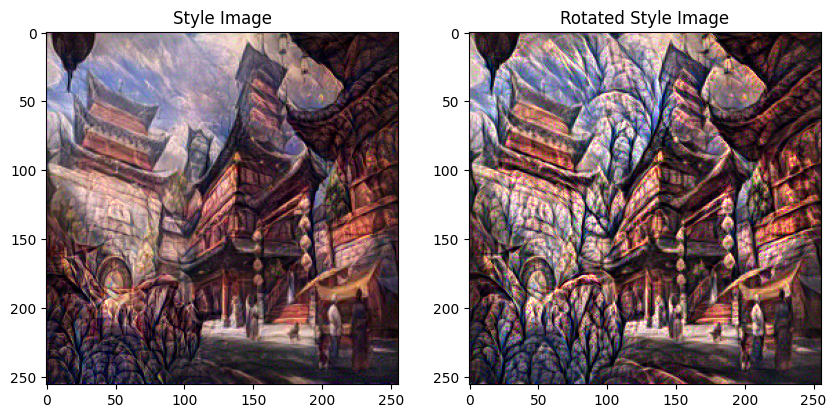

In [75]:
# --- Display the images ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5)) #Create 1 row and 2 columns
ax[0].imshow(image1) #Show first image
ax[0].set_title("Style Image") #Set title
ax[1].imshow(image2)  # Show second image
ax[1].set_title("Rotated Style Image") #Set title
plt.show()